
# 01 – Explore Data (AlphaEarth + IrrMapper CSVs)

This notebook helps you quickly explore Earth Engine export CSVs:
- Load a glob of files and merge them
- Check required columns, missing data, basic stats
- See label distribution overall and by year/state/county
- Detect duplicate `.geo` locations
- Inspect feature–label correlations
- Plot a few quick histograms

> **Tip:** set `DATA_GLOB` in the config cell first.


In [14]:

# ==== Config ====
DATA_GLOB = "../raw_data/*unbalanced_20*.csv"        # e.g., "raw_data/*training*.csv"
SAMPLE_N = 5000                    # set to an integer to sample rows for faster plotting, e.g., 200_000
DETECT_YEAR_FROM_FILENAMES = True   # if no 'year' column, extract 20xx from file names

# ==== Imports ====
from pathlib import Path
import glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from irr.constants import FEATURES, LABEL_COL

print("Expecting features:", len(FEATURES), FEATURES[:5], "...")
print("LABEL_COL:", LABEL_COL)


Expecting features: 64 ['A00', 'A01', 'A02', 'A03', 'A04'] ...
LABEL_COL: label


In [15]:

# Find files
paths = sorted(glob.glob(DATA_GLOB))
if not paths:
    raise FileNotFoundError(f"No CSV files matched: {DATA_GLOB}")
print(f"Matched {len(paths)} file(s):")
for p in paths[:10]:
    print(" •", p)
if len(paths) > 10:
    print(" ...", len(paths)-10, "more")

# Load & concatenate
dfs = []
for p in paths:
    df = pd.read_csv(p)
    df["_source_path"] = p
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f"Combined shape: {raw.shape}")
display(raw.head(3))


Matched 5 file(s):
 • ../raw_data/WA_alphaearth_irrmapper_unbalanced_2018.csv
 • ../raw_data/WA_alphaearth_irrmapper_unbalanced_2019.csv
 • ../raw_data/WA_alphaearth_irrmapper_unbalanced_2020.csv
 • ../raw_data/WA_alphaearth_irrmapper_unbalanced_2021.csv
 • ../raw_data/WA_alphaearth_irrmapper_unbalanced_2022.csv
Combined shape: (47335, 73)


,system:index,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A62,A63,cdl_code,county,county_fips,county_name,label,year,.geo,_source_path
0,0,0.130165,0.062991,-0.103406,-0.059116,0.192910,0.301423,0.236463,-0.088827,0.066990,...,0.147697,-0.000246,36,<Feature>,39,Klickitat,0,2018,"{""type"":""Point"",""coordinates"":[-120.7185706555...",../raw_data/WA_alphaearth_irrmapper_unbalanced...
1,1,0.071111,-0.166336,-0.075356,-0.079723,0.038447,0.103406,-0.008858,0.284444,0.135886,...,0.228897,0.130165,142,<Feature>,65,Stevens,0,2018,"{""type"":""Point"",""coordinates"":[-118.0290637443...",../raw_data/WA_alphaearth_irrmapper_unbalanced...
2,2,0.124567,0.160000,0.044844,-0.059116,0.135886,0.251965,0.088827,-0.002215,0.160000,...,0.022207,0.012057,152,<Feature>,25,Grant,0,2018,"{""type"":""Point"",""coordinates"":[-119.9998450231...",../raw_data/WA_alphaearth_irrmapper_unbalanced...


In [16]:

missing = [c for c in FEATURES + [LABEL_COL] if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# basic missingness
na_counts = raw[FEATURES + [LABEL_COL]].isna().sum().sort_values(ascending=False)
print("Top missing counts:")
display(na_counts.head(15))

# Make a cleaned copy for metrics
df = raw.dropna(subset=FEATURES + [LABEL_COL]).copy()
# Ensure label is 0/1
df[LABEL_COL] = (pd.to_numeric(df[LABEL_COL], errors="coerce").fillna(0) > 0).astype(int)
print(f"After dropna on features+label: {df.shape}")


Top missing counts:


A00    0
A33    0
A35    0
A36    0
A37    0
A38    0
A39    0
A40    0
A41    0
A42    0
A43    0
A44    0
A45    0
A46    0
A47    0
dtype: int64

After dropna on features+label: (47335, 73)


In [17]:

if SAMPLE_N is not None and len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=88).reset_index(drop=True)
    print(f"Downsampled to {len(df):,} rows for speed.")


Downsampled to 5,000 rows for speed.


In [18]:

if "year" not in df.columns and DETECT_YEAR_FROM_FILENAMES:
    years = df["_source_path"].astype(str).apply(lambda s: int(re.search(r"20\d{2}", s).group()) if re.search(r"20\d{2}", s) else -1)
    df["year"] = years
    print("Added 'year' column from filenames.")
    
print("Columns:", list(df.columns)[:15], "...")


Columns: ['system:index', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13'] ...


Total rows: 5,000 | 0s: 4,724 | 1s: 276 | Pos rate=5.520%


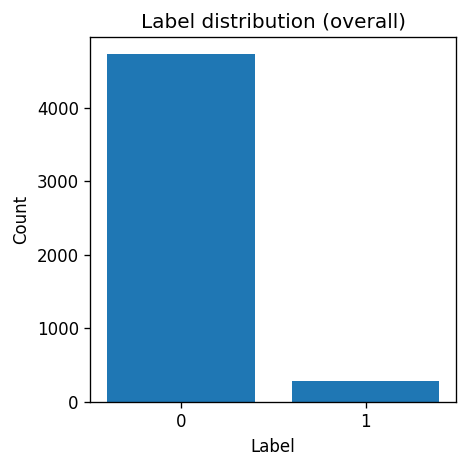

In [19]:

# Overall label distribution
vc = df[LABEL_COL].value_counts().sort_index()
n0 = int(vc.get(0, 0))
n1 = int(vc.get(1, 0))
p1 = n1 / max(n0+n1, 1)
print(f"Total rows: {len(df):,} | 0s: {n0:,} | 1s: {n1:,} | Pos rate={p1:.3%}")

plt.figure(figsize=(4,4), dpi=120)
plt.bar(["0","1"], [n0, n1])
plt.title("Label distribution (overall)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


label,0,1
year,,
2018,936,52
2019,920,61
2020,956,61
2021,989,60
2022,923,42


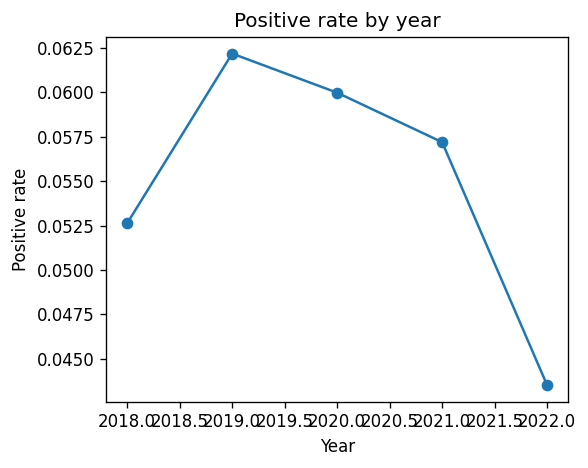

In [20]:

# By year (if available)
if "year" in df.columns:
    by_year = df.groupby("year")[LABEL_COL].value_counts().unstack(fill_value=0).sort_index()
    display(by_year.head(10))
    
    plt.figure(figsize=(5,4), dpi=120)
    by_year_ratio = (by_year[1] / (by_year[0] + by_year[1]).replace(0, np.nan)).fillna(0)
    plt.plot(by_year_ratio.index, by_year_ratio.values, marker="o")
    plt.xlabel("Year")
    plt.ylabel("Positive rate")
    plt.title("Positive rate by year")
    plt.tight_layout()
    plt.show()
else:
    print("No 'year' column; skipping year breakdown.")


In [21]:

# By state (if present)
if "state" in df.columns:
    by_state = df.groupby("state")[LABEL_COL].value_counts().unstack(fill_value=0).sort_index()
    display(by_state)
    
    plt.figure(figsize=(6,4), dpi=120)
    pos_rate = (by_state[1] / (by_state[0] + by_state[1]).replace(0, np.nan)).fillna(0)
    plt.bar(pos_rate.index, pos_rate.values)
    plt.xlabel("State")
    plt.ylabel("Positive rate")
    plt.title("Positive rate by state")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'state' column; skipping state breakdown.")


No 'state' column; skipping state breakdown.


label,0,1
county,,
<Feature>,4724,276


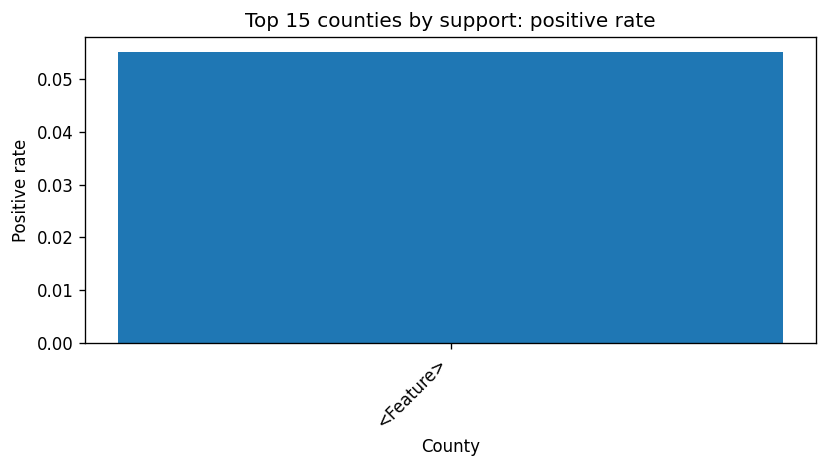

In [22]:

# By county (try common column names)
county_col = None
for cand in ["county", "county_name", "county_fips"]:
    if cand in df.columns:
        county_col = cand
        break

if county_col:
    by_county = df.groupby(county_col)[LABEL_COL].value_counts().unstack(fill_value=0)
    # Show top 15 counties by support
    by_county["support"] = by_county[0] + by_county[1]
    top = by_county.sort_values("support", ascending=False).head(15)
    display(top.drop(columns=["support"]))
    
    plt.figure(figsize=(7,4), dpi=120)
    pos_rate_cnty = (top[1] / (top[0] + top[1]).replace(0, np.nan)).fillna(0)
    plt.bar(pos_rate_cnty.index.astype(str), pos_rate_cnty.values)
    plt.xlabel("County")
    plt.ylabel("Positive rate")
    plt.title("Top 15 counties by support: positive rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No county column found; skipping county breakdown.")


In [23]:

# Duplicate check by '.geo' (if present)
if ".geo" in df.columns:
    geo = df[".geo"].astype(str)
    n_unique = geo.nunique(dropna=False)
    dup_rate = 1.0 - (n_unique / len(df)) if len(df) else 0.0
    print(f"Unique .geo: {n_unique:,} / {len(df):,} rows | duplicate rate: {dup_rate:.2%}")
else:
    print("No '.geo' column; skipping duplicate .geo check.")


Unique .geo: 4,489 / 5,000 rows | duplicate rate: 10.22%


In [24]:

# Feature summary stats
feat_df = df[FEATURES].astype(float)
desc = feat_df.describe().T  # count, mean, std, min, 25%, 50%, 75%, max
display(desc.head(10))
print(f"(Features table length: {len(desc)})")


,count,mean,std,min,25%,50%,75%,max
A00,5000.0,0.067996,0.083709,-0.284444,0.022207,0.084214,0.130165,0.267958
A01,5000.0,-0.024877,0.098352,-0.374256,-0.093564,-0.022207,0.048228,0.259900
A02,5000.0,-0.089597,0.073272,-0.292872,-0.141730,-0.088827,-0.041584,0.160000
A03,5000.0,-0.055703,0.076957,-0.301423,-0.108512,-0.055363,-0.003937,0.199862
A04,5000.0,0.071468,0.076809,-0.141730,0.012057,0.066990,0.130165,0.318893
A05,5000.0,0.021468,0.131354,-0.336855,-0.075356,0.007443,0.119093,0.346021
A06,5000.0,0.047238,0.096480,-0.186082,-0.022207,0.035433,0.108512,0.346021
A07,5000.0,0.068172,0.120414,-0.284444,-0.032541,0.066990,0.172795,0.346021
A08,5000.0,0.099892,0.092128,-0.276140,0.041584,0.098424,0.166336,0.355309
A09,5000.0,-0.056138,0.080979,-0.383914,-0.103406,-0.048228,0.000246,0.221453


(Features table length: 64)


Top + correlations:


,A35,A51,A46,A40,A26,A02,A47,A13,A48,A10
corr,0.367837,0.334661,0.296164,0.274378,0.271065,0.221468,0.209275,0.203512,0.193786,0.188483


Top - correlations:


,A38,A53,A61,A08,A25,A16,A09,A29,A45,A30
corr,-0.233857,-0.245207,-0.254055,-0.280339,-0.289047,-0.295943,-0.344693,-0.386702,-0.432811,-0.438422


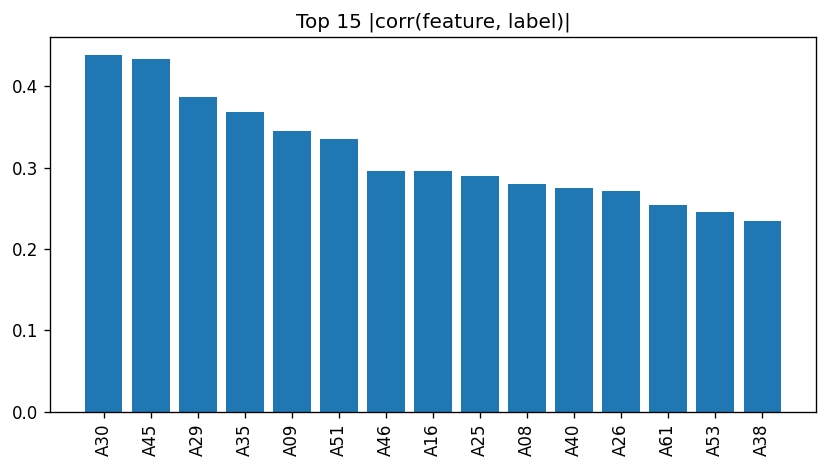

In [25]:

# Feature–label correlation (Pearson with binary label)
label = df[LABEL_COL].astype(float)
corr = feat_df.corrwith(label).sort_values(ascending=False)
top_pos = corr.head(10)
top_neg = corr.tail(10)

print("Top + correlations:")
display(top_pos.to_frame("corr").T)
print("Top - correlations:")
display(top_neg.to_frame("corr").T)

# Bar of top |corr|
top_abs = corr.abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(7,4), dpi=120)
plt.bar(top_abs.index, top_abs.values)
plt.title("Top 15 |corr(feature, label)|")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


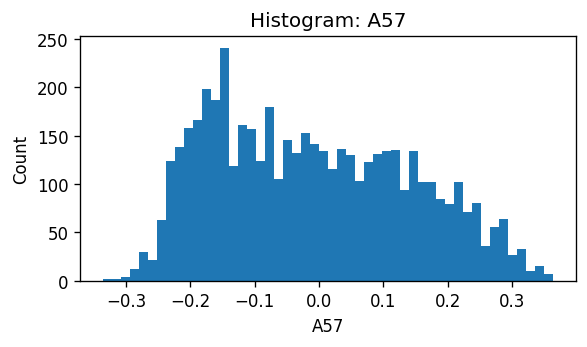

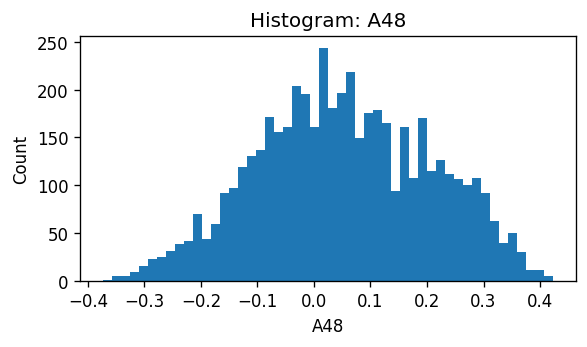

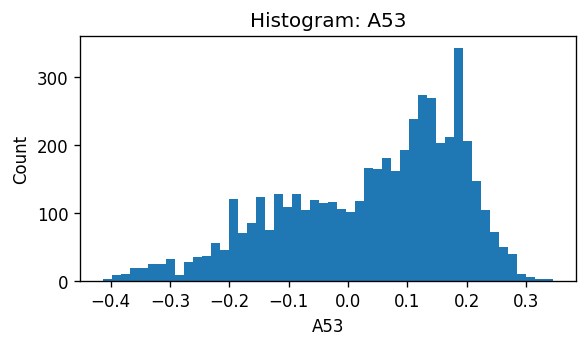

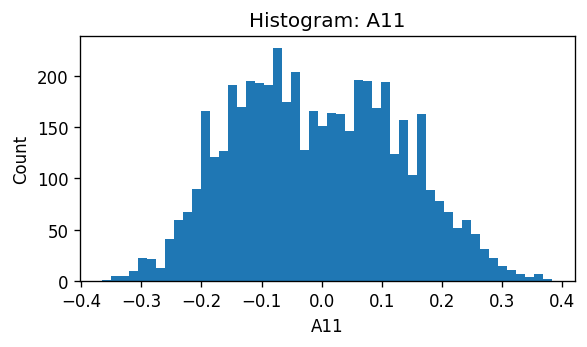

In [26]:

# Quick histograms for a few features (one plot per figure)
variances = feat_df.var().sort_values(ascending=False)
for f in variances.head(4).index:
    plt.figure(figsize=(5,3), dpi=120)
    plt.hist(feat_df[f].values, bins=50)
    plt.title(f"Histogram: {f}")
    plt.xlabel(f)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
